In [1]:
import sys
print(sys.executable)


/home/rohith/Documents/UH_DataScience/ds-chatbot/.venv/bin/python


In [2]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test  = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Columns:", train.columns.tolist())

train.head()


Train shape: (10003, 2)
Test shape : (3080, 2)
Columns: ['text', 'category']


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [3]:
train.isna().sum()


text        0
category    0
dtype: int64

/tmp/ipykernel_10201/4012969929.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


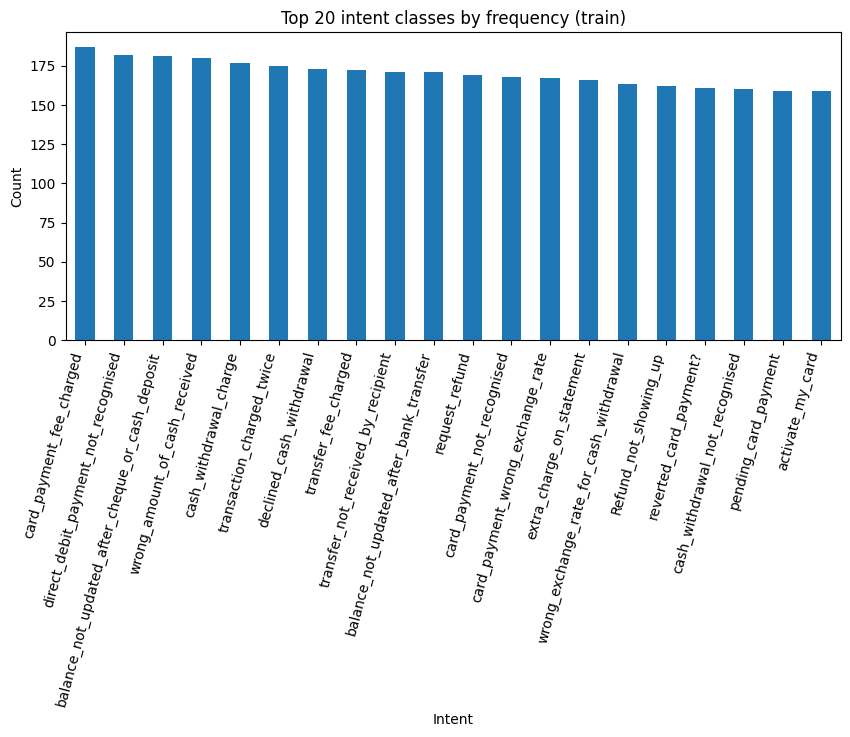

Min samples per intent: 35
Max samples per intent: 187
Mean samples per intent: 129.91


In [4]:
import matplotlib.pyplot as plt

intent_counts = train["category"].value_counts()

plt.figure(figsize=(10,4))
intent_counts.head(20).plot(kind="bar")
plt.title("Top 20 intent classes by frequency (train)")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print("Min samples per intent:", intent_counts.min())
print("Max samples per intent:", intent_counts.max())
print("Mean samples per intent:", round(intent_counts.mean(), 2))


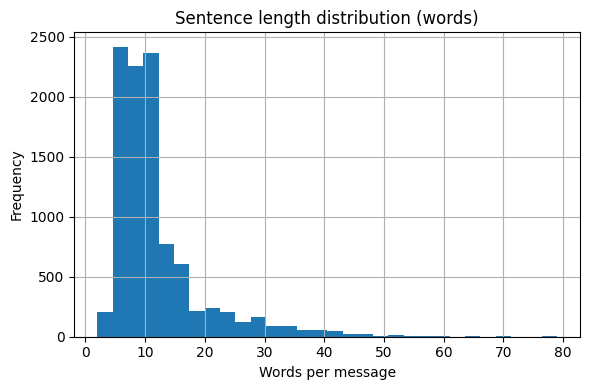

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: text_len, dtype: float64

In [5]:
train["text_len"] = train["text"].astype(str).str.split().str.len()

plt.figure(figsize=(6,4))
train["text_len"].hist(bins=30)
plt.title("Sentence length distribution (words)")
plt.xlabel("Words per message")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

train["text_len"].describe()
